In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones visuales
sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif'})

# Carga de la base (Asegúrate de que la ruta sea correcta desde tu nuevo nb)
df_base = pd.read_excel("../data/pacientes.xlsx")

# Renombre mínimo indispensable para este cálculo
df_base = df_base.rename(columns={
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',
    'Fecha egreso': 'fecha_egreso',
    'Motivo': 'motivo_egreso',
    'Nombre Hospital': 'hospital_origen'
})

# Parseo de fechas (crítico)
df_base['fecha_ingreso'] = pd.to_datetime(df_base['fecha_ingreso'], errors='coerce')
df_base['fecha_egreso'] = pd.to_datetime(df_base['fecha_egreso'], errors='coerce')

### ⚠️ OPCIÓN B (Clúster 3): Lógica suelta de ordenamiento
*Nota: Ordenamiento por paciente y fecha con filtrado manual de motivos. Debe verificarse si la versión modular oficial lo cubre completo.*

In [2]:
# 1. ORDEN CRÍTICO: Por paciente y luego por fecha cronológica
df_base = df_base.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)

# 2. AGRUPACIÓN: Sacamos la "foto completa" de cada paciente
df_trayectorias = df_base.groupby('paciente_id').agg(
    fecha_ingreso_primera=('fecha_ingreso', 'first'),
    fecha_egreso_ultima=('fecha_egreso', 'last'),
    motivo_ultimo_egreso=('motivo_egreso', 'last'), # El estado FINAL del expediente
    cantidad_nodos=('hospital_origen', 'count')
).reset_index()

# 3. CÁLCULOS DERIVADOS
df_trayectorias['cantidad_traslados'] = df_trayectorias['cantidad_nodos'] - 1

# Días en el sistema (usando tu método de redondeo hacia arriba)
df_trayectorias['dias_en_sistema'] = np.ceil(
    (df_trayectorias['fecha_egreso_ultima'] - df_trayectorias['fecha_ingreso_primera']).dt.total_seconds() / 86400
).astype('Int64')

In [3]:
df_base.groupby('paciente_id')['motivo_egreso'].last().value_counts()

motivo_egreso
alta-domiciliaria              17158
muerte                          2691
otro                            2566
traslado-otro                   2520
anulado                          932
traslado-hospital-de-la-red      694
traslado-extra-sanitario         301
Name: count, dtype: int64

In [4]:
# 4. DEFINIR CIERRES VÁLIDOS DE HISTORIA CLÍNICA
# Usamos exactamente los strings que confirmamos en el value_counts
motivos_validos = [
    'alta-domiciliaria',         # Cierre natural
    'muerte',                    # Cierre natural
    'traslado-otro',             # Salió de nuestra red (cierre válido para nuestro alcance)
    'traslado-extra-sanitario'   # Traslado a hotel/domicilio (cierre natural)
]

# 5. APLICAR FILTRO DE CALIDAD
# Filtramos pacientes cuyo ÚLTIMO estado sea un cierre válido
mask_cierre_valido = df_trayectorias['motivo_ultimo_egreso'].isin(motivos_validos)

# También nos aseguramos de que no haya días negativos por errores de fechas
mask_dias_validos = (df_trayectorias['dias_en_sistema'] >= 0) & (df_trayectorias['dias_en_sistema'].notna())

# Creamos el DataFrame ultra-limpio
df_limpio = df_trayectorias[mask_cierre_valido & mask_dias_validos].copy()

# 6. PRINT DE AUDITORÍA Y CALIDAD DE DATOS
print("--- REPORTE DE LIMPIEZA DE TRAYECTORIAS ---")
print(f"Total pacientes originales (únicos): {len(df_trayectorias)}")
print(f"Pacientes retenidos (trayectoria completa y cerrada): {len(df_limpio)}")
print(f"Pacientes descartados (truncados/anulados/otro): {len(df_trayectorias) - len(df_limpio)}")

--- REPORTE DE LIMPIEZA DE TRAYECTORIAS ---
Total pacientes originales (únicos): 27295
Pacientes retenidos (trayectoria completa y cerrada): 19310
Pacientes descartados (truncados/anulados/otro): 7985


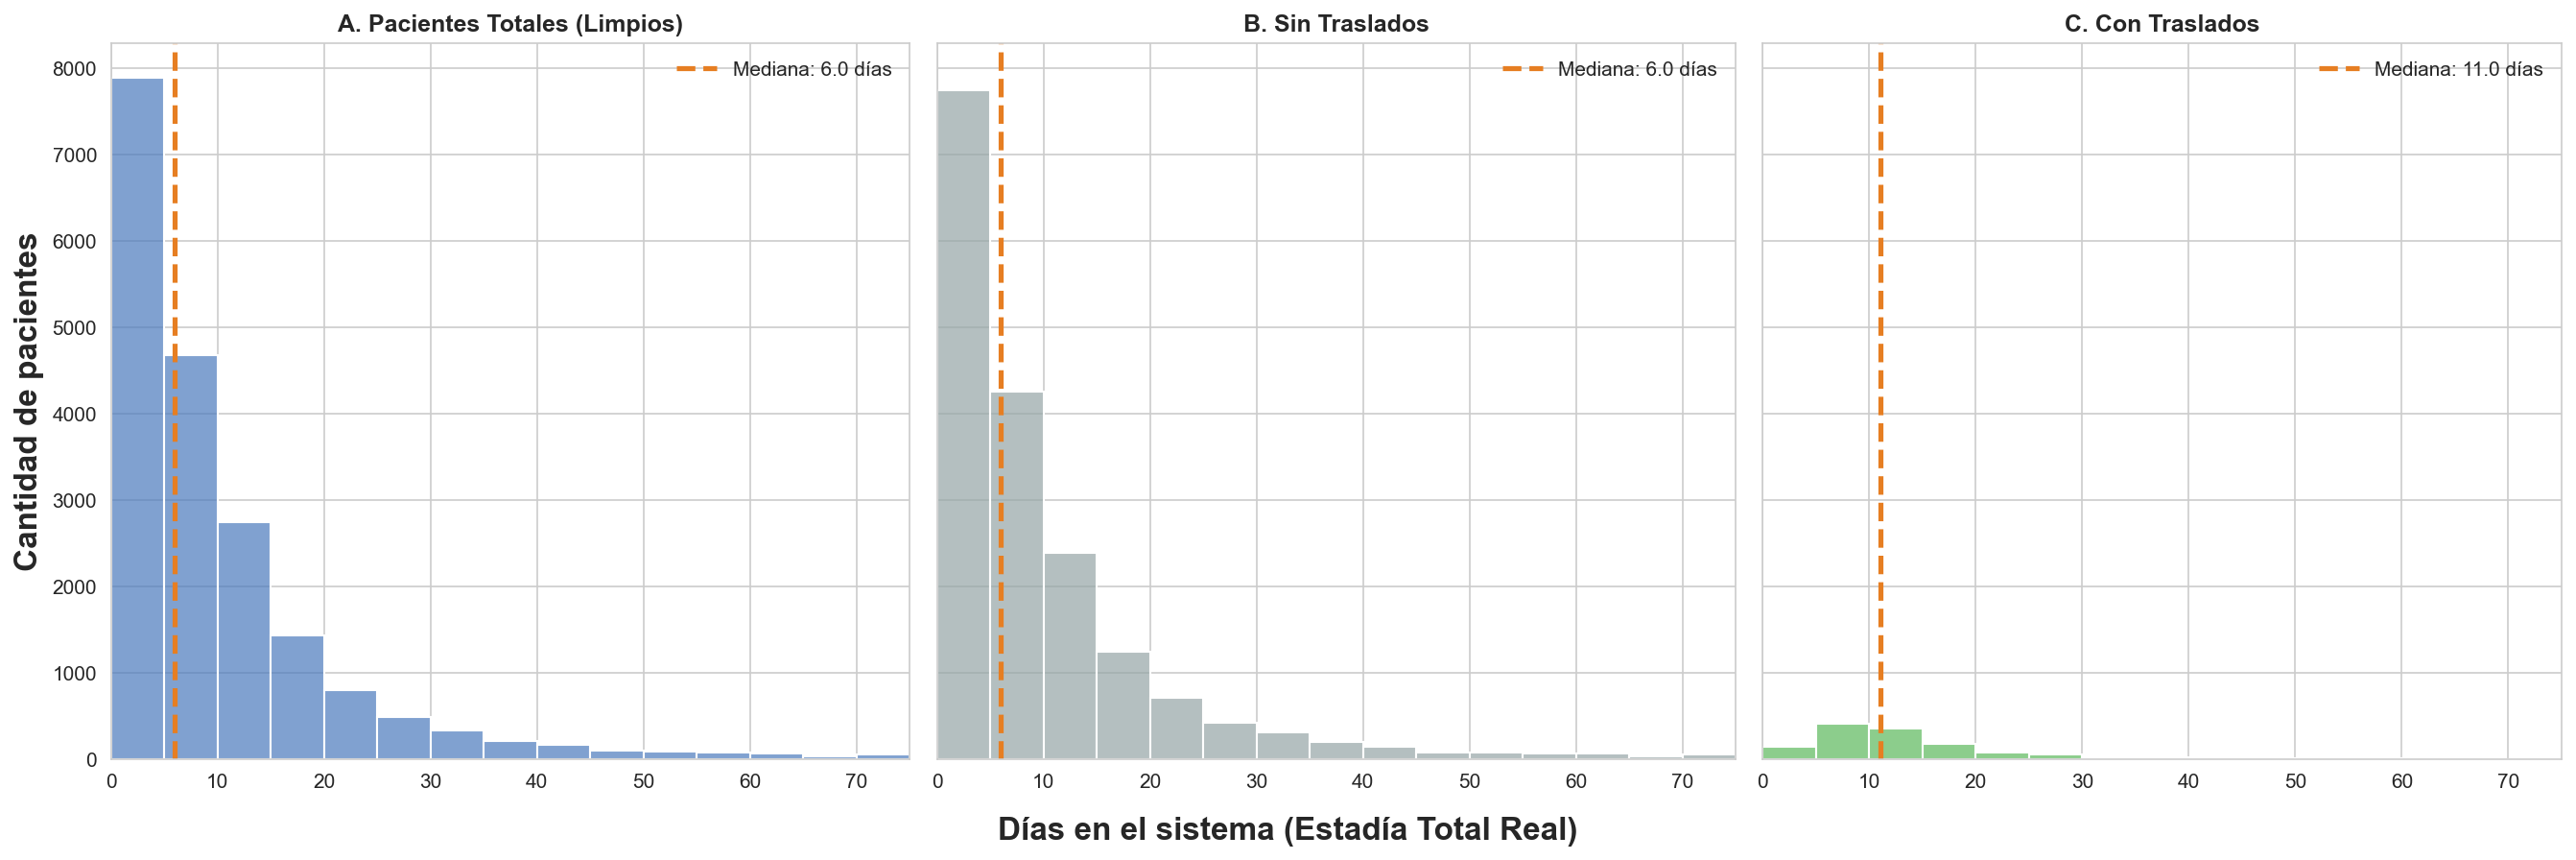

In [5]:
# Separar los universos limpios
df_sin_traslado = df_limpio[df_limpio['cantidad_traslados'] == 0]
df_con_traslado = df_limpio[df_limpio['cantidad_traslados'] > 0]

COLOR_PRINCIPAL = '#4a7abc'  # Global
COLOR_NEUTRO = '#95a5a6'     # Sin Traslado
COLOR_ACENTO = '#5cb85c'     # Trasladados

max_plot = int(df_limpio['dias_en_sistema'].quantile(0.99)) # Cortamos el 1% de outliers extremos
bins_5dias = np.arange(0, max_plot + 5, 5)

config_graficos = [
    (df_limpio, "A. Pacientes Totales (Limpios)", COLOR_PRINCIPAL),
    (df_sin_traslado, "B. Sin Traslados", COLOR_NEUTRO),
    (df_con_traslado, "C. Con Traslados", COLOR_ACENTO)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor('white')

for i, (ax, (df_plot, titulo, color)) in enumerate(zip(axes, config_graficos)):
    sns.histplot(data=df_plot, x='dias_en_sistema', bins=bins_5dias, 
                 color=color, stat='count', alpha=0.7, ax=ax, edgecolor='white')
    
    mediana = df_plot['dias_en_sistema'].median()
    ax.axvline(mediana, color='#e67e22', linestyle='--', linewidth=2.5, label=f'Mediana: {mediana:.1f} días')
    
    ax.set_xlim(0, max_plot)
    ax.set_xlabel("") 
    if i == 0:
        ax.set_ylabel("Cantidad de pacientes", fontsize=16, fontweight='bold')
    
    ax.set_title(titulo, fontweight='bold')
    ax.legend(frameon=False, loc='upper right')

fig.text(0.5, 0.02, 'Días en el sistema (Estadía Total Real)', ha='center', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1]) 
plt.show()